# Phase 3b: Width-Only µP Comparison
## SVG Scaling Laws - CS-GY 6923 Optional Project

The Phase 3 (notebook `03_mup_study.ipynb`) µP comparison was potentially confounded by
varying depth and heads alongside width. This notebook runs the clean,
confound-free version: a 5-model family that only varies `d_model` and
`d_ff`, with `n_layers=6` and `n_heads=4` fixed across all sizes.

| Name      | d_model | n_layers | n_heads | d_ff |
|-----------|---------|----------|---------|------|
| w_xs      | 128     | 6        | 4       | 512  |
| w_small   | 192     | 6        | 4       | 768  |
| w_medium  | 256     | 6        | 4       | 1024 |
| w_large   | 384     | 6        | 4       | 1536 |
| w_xl      | 512     | 6        | 4       | 2048 |

Under µP with `base_d_model = 4 × BASE_HEAD_DIM = 128`, `w_xs` *is* the literal
base (width_mult=1) and every larger model has unambiguous width_mult
(1.5×, 2×, 3×, 4×). This is the setup µP is designed for.

**Pipeline:**
1. Mount Drive & clone repo, install deps
2. Configure paths — use the original Phase 1 binaries (`outputs/data/binary/`),
   not the balanced corpus, so this comparison is on the same data Phase 2/3 used
3. SP LR sweep on `w_xs` (`scripts/06b_lr_sweep_width_only.py`)
4. Train all 5 SP width-only models (1 epoch each) at the swept LR
5. µP LR sweep on `w_xs` (`scripts/08b_lr_sweep_mup_width_only.py`)
6. Train all 5 µP width-only models (1 epoch each) at the swept LR
7. Fit power laws to both, plot on shared axes (`scripts/14_width_only_scaling.py`)

All outputs go to files with `width_only` in the name. Phase 2/3 results are not touched.

---
## Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/ml-extra-credit-project'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Project dir: {DRIVE_DIR}')

---
## Clone / Pull Repository

In [ ]:
REPO_URL = 'https://github.com/taahamohsin/ml-extra-credit-project'
REPO_DIR = '/content/ml-extra-credit-project'

import os
if os.path.exists(REPO_DIR):
    print('Repo already exists, pulling latest ...')
    !cd {REPO_DIR} && git pull
else:
    print('Cloning repo ...')
    !git clone {REPO_URL} {REPO_DIR}

os.chdir(REPO_DIR)
!git checkout balanced-rerun
print(f'Working directory: {os.getcwd()}')

Repo already exists, pulling latest ...
Already up to date.
Already on 'balanced-rerun'
Your branch is up to date with 'origin/balanced-rerun'.
Working directory: /content/ml-extra-credit-project


---
## Install Dependencies

In [ ]:
!pip install -q -r requirements.txt
print('All dependencies installed.')

All dependencies installed.


---
## Configure Output Paths

Symlink `outputs/` to the project Drive directory so all logs, checkpoints, and
plots persist. Width-only artifacts use a `_width_only` suffix in their filenames
and live under `outputs/checkpoints_width_only/` for ckpts — Phase 2/3 results
are not overwritten.

In [ ]:
import os, shutil

REPO_DIR      = '/content/ml-extra-credit-project'
DRIVE_OUTPUTS = '/content/drive/MyDrive/ml-extra-credit-project/outputs'
LOCAL_OUTPUTS = os.path.join(REPO_DIR, 'outputs')

os.makedirs(DRIVE_OUTPUTS, exist_ok=True)

if os.path.exists(LOCAL_OUTPUTS) and not os.path.islink(LOCAL_OUTPUTS):
    if os.listdir(LOCAL_OUTPUTS):
        print('Moving existing local outputs to Drive ...')
        shutil.copytree(LOCAL_OUTPUTS, DRIVE_OUTPUTS, dirs_exist_ok=True)
    shutil.rmtree(LOCAL_OUTPUTS)

if not os.path.islink(LOCAL_OUTPUTS):
    os.symlink(DRIVE_OUTPUTS, LOCAL_OUTPUTS)
    print(f'Created symlink: {LOCAL_OUTPUTS} → {DRIVE_OUTPUTS}')
else:
    print(f'Symlink already exists: {LOCAL_OUTPUTS} → {os.readlink(LOCAL_OUTPUTS)}')

for subdir in [
    'logs',
    'plots',
    'checkpoints_width_only/sp',
    'checkpoints_width_only/mup',
]:
    os.makedirs(os.path.join(DRIVE_OUTPUTS, subdir), exist_ok=True)

print('Directory structure ready.')

Created symlink: /content/ml-extra-credit-project/outputs → /content/drive/MyDrive/ml-extra-credit-project/outputs
Directory structure ready.


---
## SP LR Sweep on `w_xs`

9 LRs × 2000 steps each on the smallest model. Saves to:
- `outputs/logs/lr_sweep_width_only_sp.json`
- `outputs/plots/lr_sweep_width_only_sp.png`


In [ ]:
!python scripts/06b_lr_sweep_width_only.py

Device: cuda
SP LR sweep (width_only / w_xs): 9 values × 2000 steps each
LRs: [3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

[1/9] lr=3.0e-05 ... val=6.1640  (116s)
[2/9] lr=1.0e-04 ... val=4.9787  (103s)
[3/9] lr=3.0e-04 ... val=4.2485  (103s)
[4/9] lr=1.0e-03 ... val=6.2331  (103s)
[5/9] lr=3.0e-03 ... val=7.0594  (103s)
[6/9] lr=1.0e-02 ... DIVERGED  (103s)
[7/9] lr=3.0e-02 ... DIVERGED  (103s)
[8/9] lr=1.0e-01 ... DIVERGED  (103s)
[9/9] lr=3.0e-01 ... DIVERGED  (103s)

Best SP LR (width_only): 3.0e-04  →  val_loss=4.2485
Results saved to /content/ml-extra-credit-project/outputs/logs/lr_sweep_width_only_sp.json
LR sweep plot saved to /content/ml-extra-credit-project/outputs/plots/lr_sweep_width_only_sp.png

          LR     Val loss   Diverged
--------------------------------------
     3.0e-05       6.1640      False  
     1.0e-04       4.9787      False  
     3.0e-04       4.2485      False *
     1.0e-03       6.2331      False  
     3.0e-03       7.0594      Fal

mtime: Fri May  1 05:06:00 2026
size:  65.3 KB


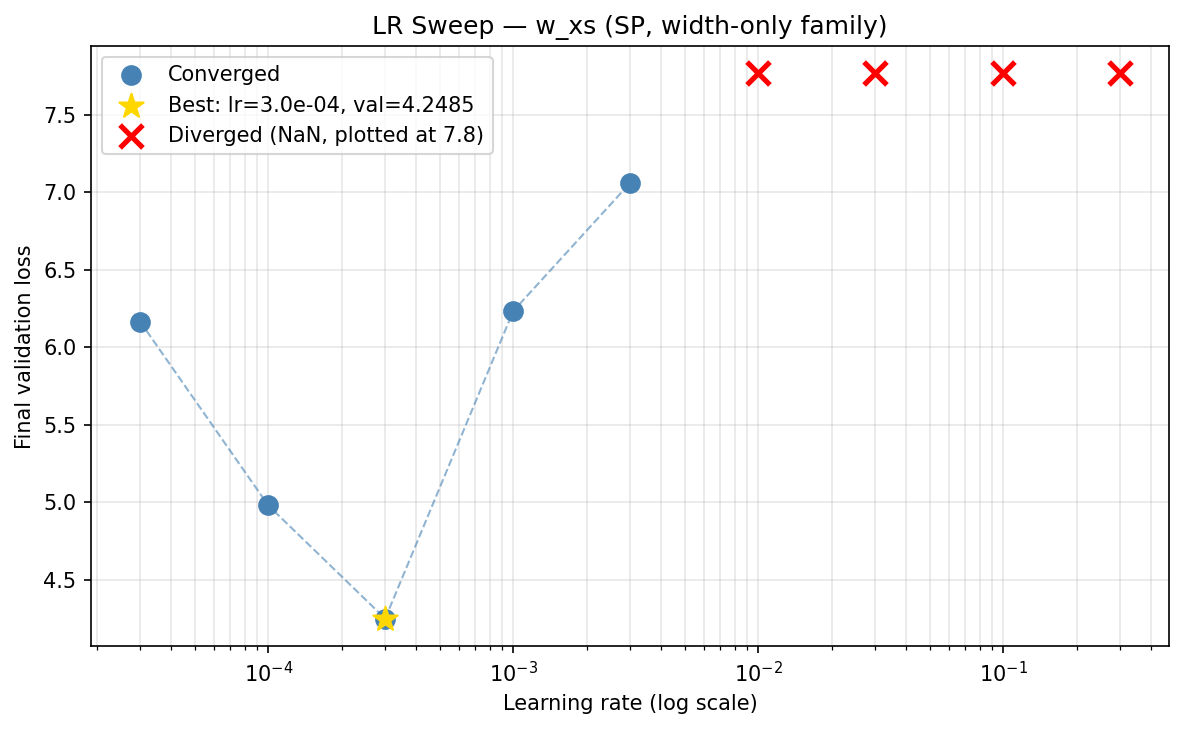

In [ ]:
from IPython.display import Image, display
import os, time

p = 'outputs/plots/lr_sweep_width_only_sp.png'
print(f'mtime: {time.ctime(os.path.getmtime(p))}')
print(f'size:  {os.path.getsize(p)/1e3:.1f} KB')
display(Image(p))


---
## Train All 5 SP Width-Only Models

Uses the SP LR found above. Each model runs for 1 epoch to match the
Phase 2 protocol. Outputs:
- `outputs/logs/result_<name>_width_only_sp.json` (per model)
- `outputs/checkpoints_width_only/sp/<name>/` (checkpoints)
- `outputs/logs/training_<name>_width_only_sp.csv` (per-step log)


In [ ]:
import json

sweep = json.load(open('outputs/logs/lr_sweep_width_only_sp.json'))
SP_LR = sweep['best_lr']
print(f'Training all 5 SP width-only models at lr={SP_LR:.1e}\n')

for name in ['w_xs', 'w_small', 'w_medium', 'w_large', 'w_xl']:
    print(f'\n{"="*60}')
    print(f'SP — {name}')
    print(f'{"="*60}')
    !python scripts/05_train_model.py \
        --config_family width_only \
        --model_name {name} \
        --lr {SP_LR} \
        --epochs 1 \
        --ckpt_dir outputs/checkpoints_width_only/sp \
        --result_suffix _width_only_sp

Training all 5 SP width-only models at lr=3.0e-04


SP — w_xs
Device: cuda
Compiling model with torch.compile ...
Model: w_xs  |  Non-emb params: 1,189,888
Train tokens: 130,404,653  |  steps/epoch: 1,989  |  epochs: 1  |  total steps: 1,989

Training: W_XS
  Non-emb params:  1,189,888
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Tokens/step:     65,536  (seq_len=1024)
  Epochs:          1
  Steps/epoch:     1,989
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/w_xs/
  Drive ckpts:     /content/ml-extra-credit-project/outputs/checkpoints_width_only/sp/w_xs/
  Log:             /content/ml-extra-credit-project/outputs/logs/training_w_xs.csv

Training w_xs for 1989 steps (bf16=True, grad_accum=1)
Exception ignored in: <function WeakIdKeyDictionary.__init__.<locals>.remove at 0x7ab4089611c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/weak.py", line 1

In [ ]:
!python scripts/05_train_model.py --model_name w_xs --config_family width_only --lr 3e-4

Device: cuda
Compiling model with torch.compile ...
Model: w_xs  |  Non-emb params: 1,189,888
Train tokens: 130,404,653  |  steps/epoch: 1,989  |  epochs: 1  |  total steps: 1,989

Training: W_XS
  Non-emb params:  1,189,888
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Tokens/step:     65,536  (seq_len=1024)
  Epochs:          1
  Steps/epoch:     1,989
  Total steps:     1,989
  bf16:            True
  Local ckpts:     /tmp/checkpoints_local/w_xs/
  Drive ckpts:     /content/ml-extra-credit-project/outputs/checkpoints/w_xs/
  Log:             /content/ml-extra-credit-project/outputs/logs/training_w_xs.csv

Training w_xs for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3402 | val 8.3398 * | lr 0.00e+00 | tok 0.1M | t 0.1min | mem 603MB
step     50 | train 7.8979 | lr 7.50e-05 | tok 3.3M | t 0.1min
step    100 | train 7.0983 | lr 1.50e-04 | tok 6.6M | t 0.2min
step    150 | train 6.5169 | lr 2.25e-04 | tok 9.9M | t 0.3min
step

In [ ]:
import json

print(f'{"Model":<10} {"N params":>12} {"best_val":>10} {"final_val":>10} {"wall_min":>10}')
print('-' * 56)
for name in ['w_xs', 'w_small', 'w_medium', 'w_large', 'w_xl']:
    p = f'outputs/logs/result_{name}_width_only_sp.json'
    try:
        r = json.load(open(p))
        print(f'{name:<10} {r["n_params"]:>12,} {r["best_val_loss"]:>10.4f} '
              f'{r["final_val_loss"]:>10.4f} {r["wall_time_min"]:>10.1f}')
    except FileNotFoundError:
        print(f'{name:<10}  (result file missing: {p})')

Model          N params   best_val  final_val   wall_min
--------------------------------------------------------
w_xs          1,189,888     4.2091     4.2091        2.6
w_small       2,669,568     3.9940     3.9940        3.0
w_medium      4,739,072     3.7336     3.7336        3.1
w_large      10,647,552     3.5782     3.5782        4.2
w_xl         18,915,328     3.3936     3.3936        5.4


---
## µP LR Sweep on `w_xs`

Same 9 LRs, same 2000 steps, but with the µP parameterization. Because `w_xs` IS
the literal µP base (width_mult=1, base_d_model=128), the µP sweep at base
width should produce nearly the same optimal LR as SP — that's the µP
correctness check. Saves to:
- `outputs/logs/lr_sweep_width_only_mup.json`
- `outputs/plots/lr_sweep_width_only.png` (SP vs µP comparison)

In [ ]:
!python scripts/08b_lr_sweep_mup_width_only.py

Device: cuda
µP LR sweep (width_only / w_xs): 9 values × 2000 steps each
LRs: [3e-05, 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1, 0.3]

[1/9] lr=3.0e-05 ... val=6.1609  (108s)
[2/9] lr=1.0e-04 ... val=4.8592  (104s)
[3/9] lr=3.0e-04 ... val=4.2586  (104s)
[4/9] lr=1.0e-03 ... val=6.0134  (104s)
[5/9] lr=3.0e-03 ... val=7.5428  (104s)
[6/9] lr=1.0e-02 ... val=8.8617  (104s)
[7/9] lr=3.0e-02 ... DIVERGED  (104s)
[8/9] lr=1.0e-01 ... DIVERGED  (104s)
[9/9] lr=3.0e-01 ... DIVERGED  (104s)

Best µP LR (width_only): 3.0e-04  →  val_loss=4.2586
Results saved to /content/ml-extra-credit-project/outputs/logs/lr_sweep_width_only_mup.json
LR sweep comparison saved to /content/ml-extra-credit-project/outputs/plots/lr_sweep_width_only.png

          LR     Val loss   Diverged
--------------------------------------
     3.0e-05       6.1609      False  
     1.0e-04       4.8592      False  
     3.0e-04       4.2586      False *
     1.0e-03       6.0134      False  
     3.0e-03       7.5428   

µP best LR: 3.0e-04  (val=4.2586)

        LR   val_loss   diverged
   3.0e-05     6.1609      False
   1.0e-04     4.8592      False
   3.0e-04     4.2586      False  *
   1.0e-03     6.0134      False
   3.0e-03     7.5428      False
   1.0e-02     8.8617      False
   3.0e-02        nan       True
   1.0e-01        nan       True
   3.0e-01        nan       True



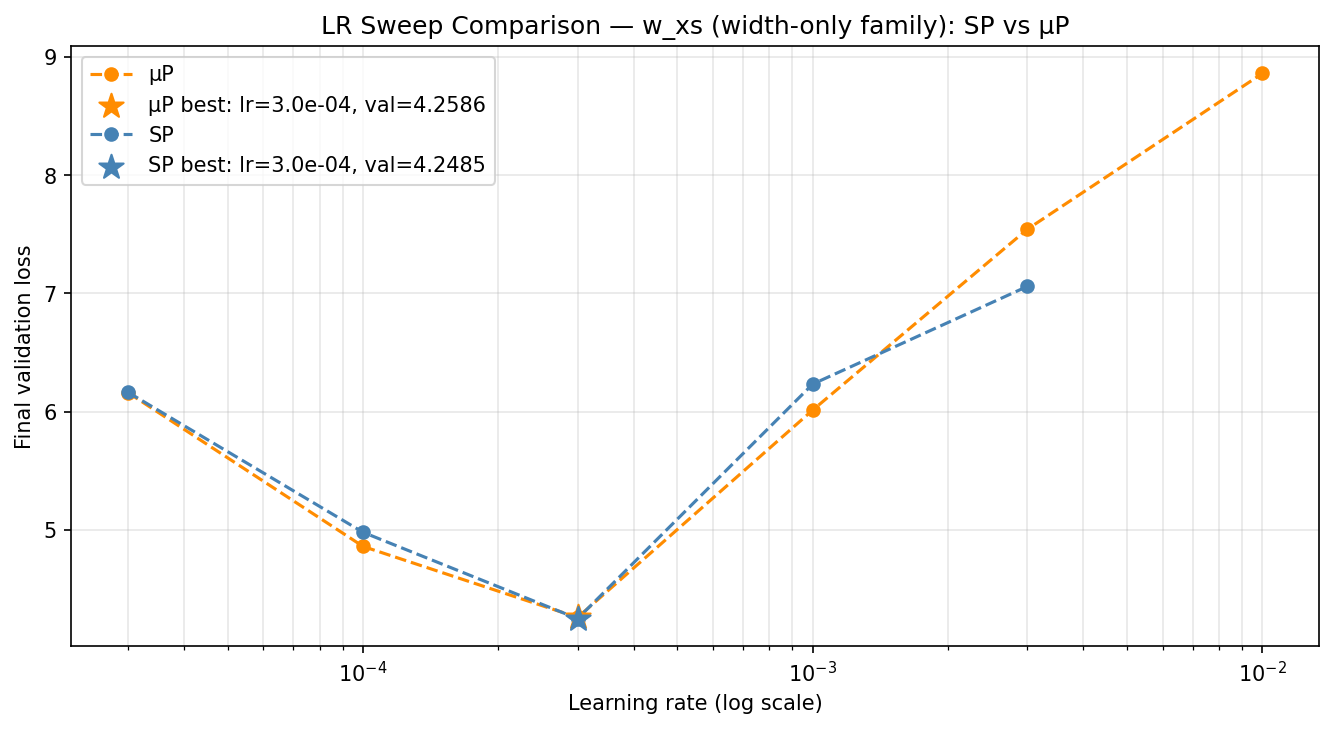


Correctness check at base width (w_xs is base for both):
  SP best:  lr=3.0e-04  val=4.2485
  µP best:  lr=3.0e-04  val=4.2586
  → SP and µP picked the same LR at base width — correctness check passed.


In [ ]:
import json
from IPython.display import Image, display

sweep = json.load(open('outputs/logs/lr_sweep_width_only_mup.json'))
print(f'µP best LR: {sweep["best_lr"]:.1e}  (val={sweep["best_val_loss"]:.4f})')
print()
print(f'{"LR":>10} {"val_loss":>10} {"diverged":>10}')
for r in sweep['runs']:
    marker = '  *' if r['lr'] == sweep['best_lr'] else ''
    print(f'{r["lr"]:>10.1e} {r["val_loss"]:>10.4f} {str(r["diverged"]):>10}{marker}')

print()
display(Image('outputs/plots/lr_sweep_width_only.png'))

sp_sweep = json.load(open('outputs/logs/lr_sweep_width_only_sp.json'))
print(f'\nCorrectness check at base width (w_xs is base for both):')
print(f'  SP best:  lr={sp_sweep["best_lr"]:.1e}  val={sp_sweep["best_val_loss"]:.4f}')
print(f'  µP best:  lr={sweep["best_lr"]:.1e}  val={sweep["best_val_loss"]:.4f}')
if sp_sweep['best_lr'] == sweep['best_lr']:
    print('  → SP and µP picked the same LR at base width — correctness check passed.')
else:
    print('  → SP and µP picked different LRs at base width — investigate before transferring µP LR.')

---
## Train All 5 µP Width-Only Models

Transfer the µP LR found above to all 5 widths. No per-width retuning since that's
the entire point of µP. Outputs:
- `outputs/logs/result_mup_<name>_width_only_mup.json` (per model)
- `outputs/checkpoints_width_only/mup/<name>/` (checkpoints)
- `outputs/logs/training_mup_<name>_width_only_mup.csv` (per-step log)


In [ ]:
import json

sweep = json.load(open('outputs/logs/lr_sweep_width_only_mup.json'))
MUP_LR = sweep['best_lr']
print(f'Training all 5 µP width-only models at lr={MUP_LR:.1e}  (transferred from w_xs sweep)\n')

for name in ['w_xs', 'w_small', 'w_medium', 'w_large', 'w_xl']:
    print(f'\n{"="*60}')
    print(f'µP — {name}')
    print(f'{"="*60}')
    !python scripts/07_train_mup.py \
        --config_family width_only \
        --model_name {name} \
        --lr {MUP_LR} \
        --ckpt_dir outputs/checkpoints_width_only/mup \
        --result_suffix _width_only_mup

Training all 5 µP width-only models at lr=3.0e-04  (transferred from w_xs sweep)


µP — w_xs
Device: cuda
Compiling model with torch.compile ...
µP Model: w_xs  |  Non-emb params: 1,189,888
Train tokens: 130,404,653  |  steps/epoch: 1,989

µP Training: W_XS
  Non-emb params:  1,189,888
  Peak LR:         3.00e-04
  Batch size:      64 seqs/step × 1 accum = 64 seqs effective
  Total steps:     1,989
  Base shapes:     in-memory (per-model)

Training mup_w_xs for 1989 steps (bf16=True, grad_accum=1)
step      0 | train 8.3388 | val 8.3395 * | lr 0.00e+00 | tok 0.1M | t 0.1min | mem 603MB
step     50 | train 7.9011 | lr 7.50e-05 | tok 3.3M | t 0.1min
step    100 | train 7.0868 | lr 1.50e-04 | tok 6.6M | t 0.2min
step    150 | train 6.5187 | lr 2.25e-04 | tok 9.9M | t 0.2min
step    200 | train 6.3118 | val 6.3053 * | lr 3.00e-04 | tok 13.2M | t 0.3min | mem 603MB
step    250 | train 6.1729 | lr 2.99e-04 | tok 16.4M | t 0.4min
step    300 | train 6.0750 | lr 2.98e-04 | tok 19.7M | t 0.4min

In [ ]:
import json

print(f'{"Model":<10} {"N params":>12} {"best_val":>10} {"final_val":>10} {"wall_min":>10}')
print('-' * 56)
for name in ['w_xs', 'w_small', 'w_medium', 'w_large', 'w_xl']:
    p = f'outputs/logs/result_mup_{name}_width_only_mup.json'
    try:
        r = json.load(open(p))
        print(f'{name:<10} {r["n_params"]:>12,} {r["best_val_loss"]:>10.4f} '
              f'{r["final_val_loss"]:>10.4f} {r["wall_time_min"]:>10.1f}')
    except FileNotFoundError:
        print(f'{name:<10}  (result file missing: {p})')

Model          N params   best_val  final_val   wall_min
--------------------------------------------------------
w_xs          1,189,888     4.2079     4.2079        2.2
w_small       2,669,568     4.1790     4.1790        2.9
w_medium      4,739,072     4.0916     4.0916        3.1
w_large      10,647,552     4.2180     4.2180        3.7
w_xl         18,915,328     4.0605     4.0605        4.7


---
## Fit Power Laws and Plot

`scripts/14_width_only_scaling.py --plot_only` skips training (we already did it
above) and goes straight to: fit `L = a·N^(−α) + c` to both SP and µP series,
plot on shared log-log axes, save fits to JSON.

Outputs:
- `outputs/plots/scaling_law_width_only.png` — both curves on one graph
- `outputs/logs/scaling_width_only_sp.json`
- `outputs/logs/scaling_width_only_mup.json`

In [ ]:
!python scripts/14_width_only_scaling.py --plot_only

Device: cuda

[plot_only] Loading saved results and replotting ...

Scaling law fit (SP)
  L = 13.3817 * N^(-0.0955) + 0.7012
  a     = 13.3817  ±  11.7187
  alpha = 0.0955  ±  0.1799
  c     = 0.7012  ±  5.8117
  R²    = 0.9892
  (Kaplan et al. NL: alpha ≈ 0.076)

Scaling law fit (µP)
  L = 4.7197 * N^(-0.0083) + 0.0000
  a     = 4.7197  ±  1356.6432
  alpha = 0.0083  ±  2.7433
  c     = 0.0000  ±  1368.8100
  R²    = 0.2833
  (Kaplan et al. NL: alpha ≈ 0.076)

Scaling law plot saved to /content/ml-extra-credit-project/outputs/plots/scaling_law_width_only.png
Fit JSON saved to /content/ml-extra-credit-project/outputs/logs/scaling_width_only_sp.json
Fit JSON saved to /content/ml-extra-credit-project/outputs/logs/scaling_width_only_mup.json


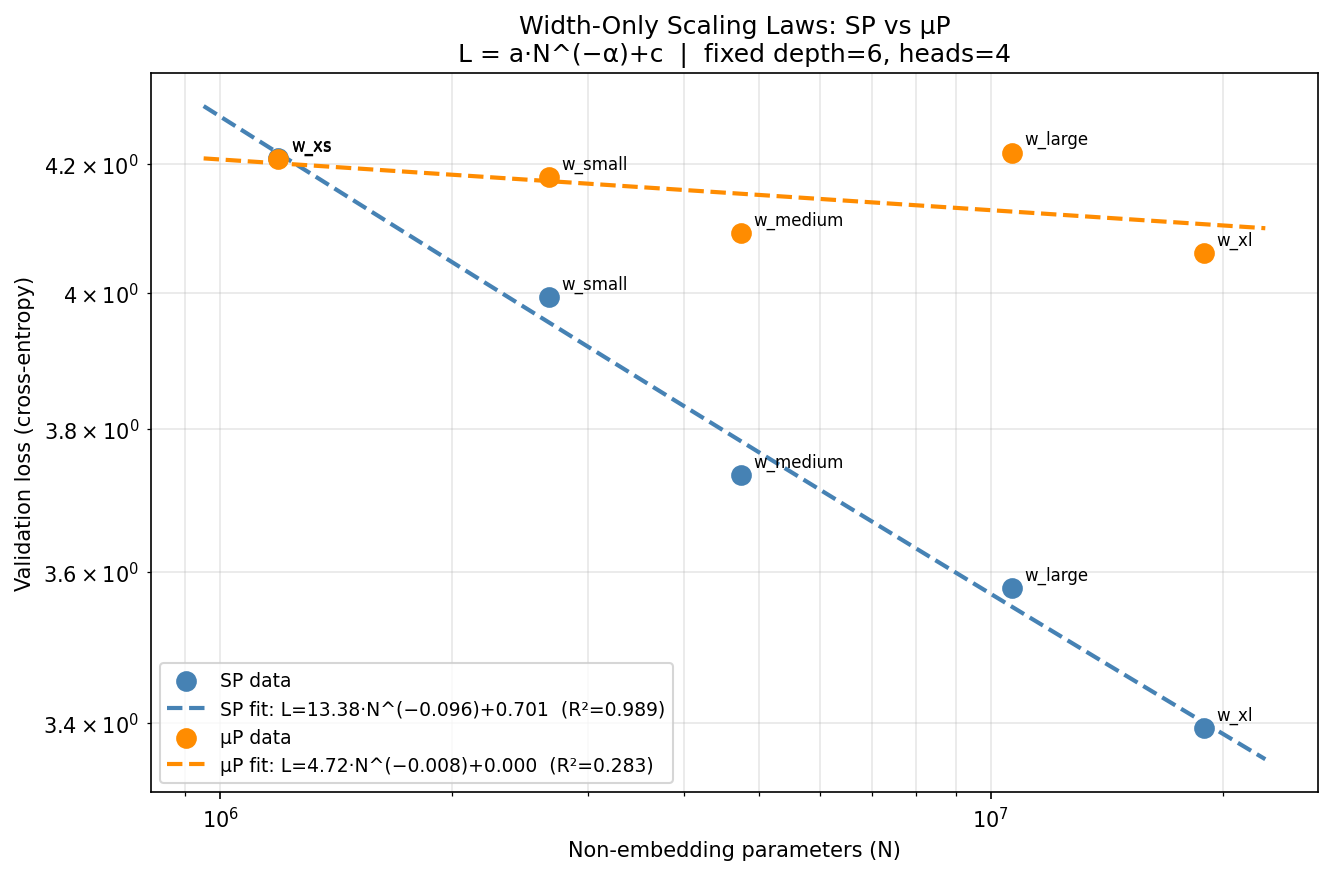


SP: L = 13.382 · N^(-0.0955) + 0.701   R²=0.9892

µP: L = 4.720 · N^(-0.0083) + 0.000   R²=0.2833


In [ ]:
from IPython.display import Image, display
import json

display(Image('outputs/plots/scaling_law_width_only.png'))

for label, fname in [('SP', 'scaling_width_only_sp.json'),
                     ('µP', 'scaling_width_only_mup.json')]:
    p = f'outputs/logs/{fname}'
    try:
        d = json.load(open(p))
        print(f'\n{label}: L = {d["a"]:.3f} · N^(-{d["alpha"]:.4f}) + {d["c"]:.3f}'
              f'   R²={d["r_squared"]:.4f}')
    except FileNotFoundError:
        print(f'\n{label}: fit JSON not found ({p})')

---
## Final Comparison Table

In [ ]:
import json

print(f'{"Model":<10} {"N params":>12} {"SP val":>10} {"µP val":>10} {"Δ (µP−SP)":>12}')
print('-' * 60)
for name in ['w_xs', 'w_small', 'w_medium', 'w_large', 'w_xl']:
    sp_p  = f'outputs/logs/result_sp_{name}_width_only.json'
    mup_p = f'outputs/logs/result_mup_{name}_width_only.json'
    try:
        sp  = json.load(open(sp_p))
        mup = json.load(open(mup_p))
        delta = mup['best_val_loss'] - sp['best_val_loss']
        sign  = '+' if delta >= 0 else ''
        print(f'{name:<10} {sp["n_params"]:>12,} '
              f'{sp["best_val_loss"]:>10.4f} {mup["best_val_loss"]:>10.4f} '
              f'{sign}{delta:>11.4f}')
    except FileNotFoundError as e:
        print(f'{name:<10}  (missing: {e.filename})')

print()
print('Width-only experiment complete.')
print('All artifacts saved to outputs/{logs,plots,checkpoints_width_only}/.')

Model          N params     SP val     µP val    Δ (µP−SP)
------------------------------------------------------------
w_xs          1,189,888     4.2091     4.2079     -0.0011
w_small       2,669,568     3.9940     4.1790 +     0.1850
w_medium      4,739,072     3.7336     4.0916 +     0.3580
w_large      10,647,552     3.5782     4.2180 +     0.6398
w_xl         18,915,328     3.3936     4.0605 +     0.6669

Width-only experiment complete.
All artifacts saved to outputs/{logs,plots,checkpoints_width_only}/.
